Successfully imported necessary libraries for descriptive analysis

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
import scipy as sc
import seaborn as sns

# Import dataframes for descriptive analysis

In [23]:
life_expectancy = pd.read_csv('../Datasets/Cleaned_datasets/Life_expectancy_cleaned_1.csv').drop(columns=['Unnamed: 0'])
print(life_expectancy.info())

highest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/Top_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])
lowest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/Lowest_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2816 entries, 0 to 2815
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        2816 non-null   object 
 1   year                           2816 non-null   int64  
 2   life_expectancy                2816 non-null   float64
 3   adult_mortality                2752 non-null   float64
 4   infant_deaths                  2752 non-null   float64
 5   under_five_deaths              2752 non-null   float64
 6   bmi_male                       2816 non-null   float64
 7   bmi_female                     2816 non-null   float64
 8   health_expenditure_percentage  2764 non-null   float64
 9   total_expenditure              2764 non-null   float64
 10  unemployment_total             2736 non-null   float64
 11  population                     2816 non-null   int64  
 12  gdp_per_capita                 2816 non-null   f

In [24]:
descriptive_stats_life_exp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_Dfs/Descriptive_Stats-All_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

descriptive_stats_adult_mortality = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_Dfs/Descriptive_Stats-All_Adult_Mortality.csv').drop(columns=['Unnamed: 0'])

# Descriptive Statistics

## Life Expectancy

In [25]:
print(descriptive_stats_life_exp)



    year   mean    max max_countries  minimum min_countries  median
0   2000  66.68  81.08         Japan    44.52        Malawi   69.74
1   2001  67.01  81.42         Japan    41.96      Zimbabwe   69.94
2   2002  67.29  81.69         Japan    44.56      Zimbabwe   70.42
3   2003  67.57  81.76         Japan    43.39      Zimbabwe   70.53
4   2004  67.93  82.03         Japan    43.71       Lesotho   70.85
5   2005  68.28  81.96         Japan    43.23       Lesotho   71.19
6   2006  68.66  82.32         Japan    42.91       Lesotho   71.18
7   2007  69.00  82.51         Japan    43.12       Lesotho   71.40
8   2008  69.33  82.59         Japan    43.57       Lesotho   71.63
9   2009  69.74  82.93         Japan    44.03       Lesotho   71.91
10  2010  70.03  82.84         Japan    45.60       Lesotho   72.32
11  2011  70.49  82.70   Switzerland    46.69       Lesotho   72.49
12  2012  70.78  83.10         Japan    47.84       Lesotho   72.56
13  2013  71.07  83.33         Japan    49.00   

### Distribution diagrams

Create distribution diagram on life expectancy data for all countries to compare life expectancies broadly between the year 2000 and 2015, with mean indicator.

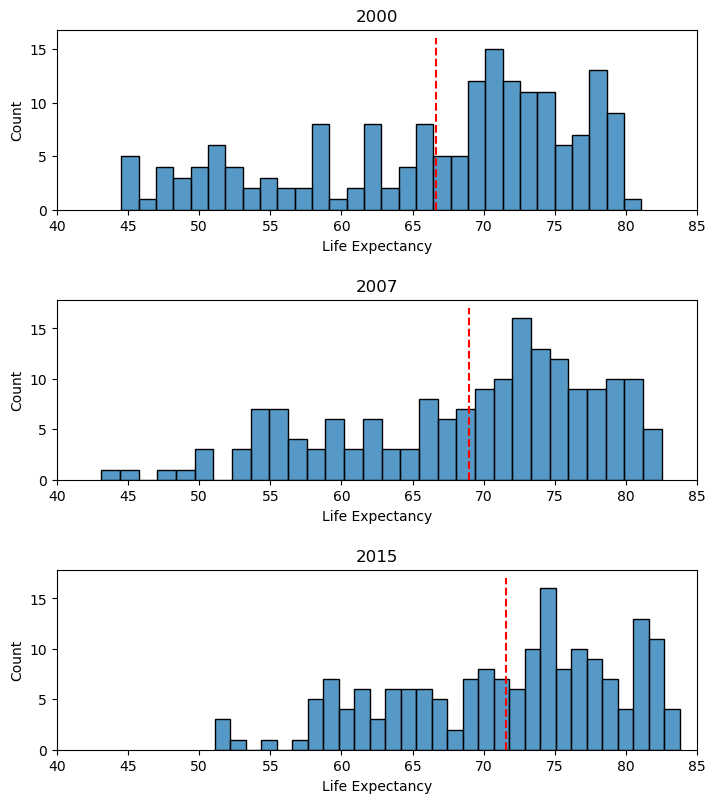

<Figure size 500x400 with 0 Axes>

Looking at the distribution diagrams for Life Expectancy in the years 2000, 2007 and 2015; A noticable positive shift of the bulk data to the right can be observed.
As the years pass higher low life expectancy can be expected.


<Figure size 640x480 with 0 Axes>

In [26]:
year_2000_le_all = life_expectancy['life_expectancy'][life_expectancy['year'] == 2000]
year_2000_le_mean = np.mean(life_expectancy['life_expectancy'][life_expectancy['year'] == 2000])
year_2007_le_all = life_expectancy['life_expectancy'][life_expectancy['year'] == 2007]
year_2007_le_mean = np.mean(life_expectancy['life_expectancy'][life_expectancy['year'] == 2007])
year_2015_le_all = life_expectancy['life_expectancy'][life_expectancy['year'] == 2015]
year_2015_le_mean = np.mean(life_expectancy['life_expectancy'][life_expectancy['year'] == 2015])


plt.subplot(3, 1, 1)
sns.histplot(list(year_2000_le_all), bins=30)
plt.subplots_adjust(0, 1, 1, 2.5, 3, 0.5)
plt.vlines(year_2000_le_mean, 0, 16, colors='red', linestyles='--')
plt.title('2000')
plt.xlabel('Life Expectancy')
plt.xlim(40, 85)
plt.subplot(3, 1, 2)
sns.histplot(list(year_2007_le_all), bins=30)
plt.vlines(year_2007_le_mean, 0, 17, colors='red', linestyles='--')
plt.title('2007')
plt.xlabel('Life Expectancy')
plt.xlim(40, 85)
plt.subplot(3, 1, 3)
sns.histplot(list(year_2015_le_all), bins=30)
plt.vlines(year_2015_le_mean, 0, 17, colors='red', linestyles='--')
plt.title('2015')
plt.xlabel('Life Expectancy')
plt.xlim(40, 85)
plt.figure(figsize= [5, 4])
plt.show()
plt.clf()

print('Looking at the distribution diagrams for Life Expectancy in the years 2000, 2007 and 2015; A noticable positive shift of the bulk data to the right can be observed.\nAs the years pass higher low life expectancy can be expected.')

### Box plots

Create boxplots of the same data to observe changes over the 16 years

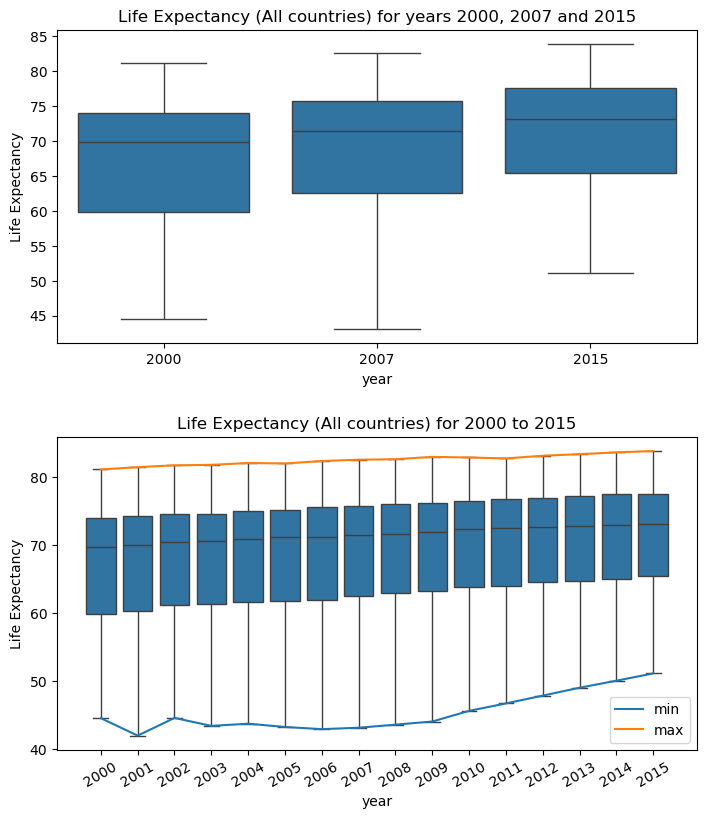

<Figure size 640x480 with 0 Axes>

In [27]:
le_all_2000_and_2015 = life_expectancy[(life_expectancy['year'] == 2000) | (life_expectancy['year'] == 2015) | (life_expectancy['year'] == 2007)]
le_all_2000_to_2015 = life_expectancy

ax1 = plt.subplot(2, 1, 1)
sns.boxplot(x = le_all_2000_and_2015['year'], y = le_all_2000_and_2015['life_expectancy'])
plt.title('Life Expectancy (All countries) for years 2000, 2007 and 2015')
plt.ylabel('Life Expectancy')
plt.subplots_adjust(0, 1, 1, 2.5, 3, 0.3)
ax2 = plt.subplot(2, 1, 2)
sns.boxplot(x = le_all_2000_to_2015['year'], y = le_all_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (All countries) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.plot(descriptive_stats_life_exp['minimum'], label = 'min')
plt.plot(descriptive_stats_life_exp['max'], label = 'max')
plt.legend()
plt.show()
plt.clf()

## Adult Mortality

In [28]:
print(descriptive_stats_adult_mortality)



    year    mean    max max_countries  minimum         min_countries  median
0   2000  215.51  682.6      Zimbabwe    64.29  United Arab Emirates  177.80
1   2001  213.33  693.9      Zimbabwe    62.81  United Arab Emirates  177.35
2   2002  211.77  704.8      Zimbabwe    61.37  United Arab Emirates  176.50
3   2003  209.97  709.9      Zimbabwe    59.90  United Arab Emirates  173.25
4   2004  207.04  707.1      Zimbabwe    58.37  United Arab Emirates  171.40
5   2005  203.98  732.5       Lesotho    56.90  United Arab Emirates  169.85
6   2006  198.95  743.5       Lesotho    55.50  United Arab Emirates  166.55
7   2007  194.45  710.9       Lesotho    53.99  United Arab Emirates  163.85
8   2008  189.67  659.6       Lesotho    52.43  United Arab Emirates  163.00
9   2009  184.84  631.4       Lesotho    50.85  United Arab Emirates  158.25
10  2010  182.52  675.7         Haiti    49.69  United Arab Emirates  155.85
11  2011  178.11  652.0       Somalia    48.94  United Arab Emirates  152.75

### Distribution diagrams

Create distribution diagram on life expectancy data for all countries to compare life expectancies broadly between the year 2000 and 2015, with mean indicator.

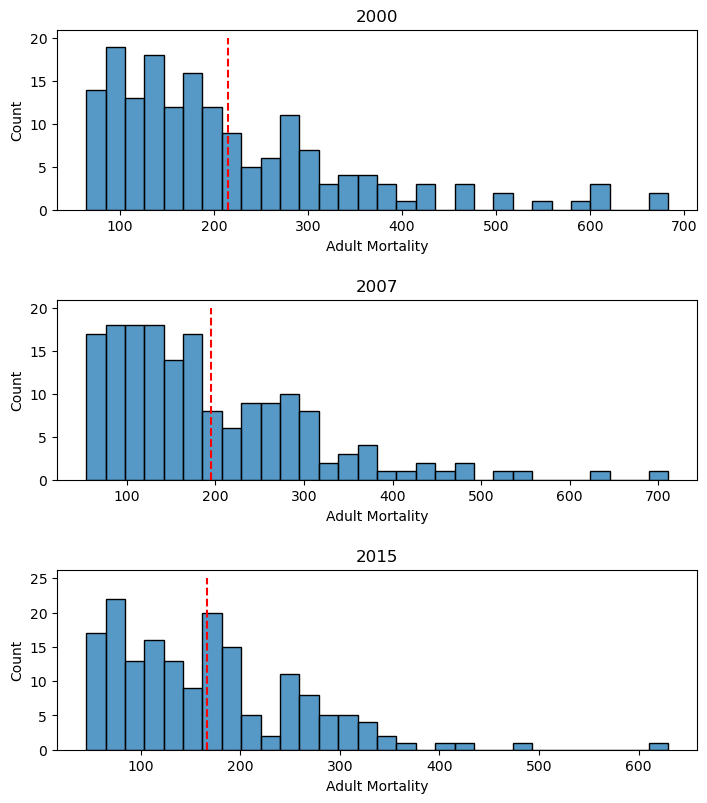

<Figure size 500x400 with 0 Axes>

Looking at the distribution diagrams for Life Expectancy in the years 2000, 2007 and 2015; A noticable positive shift of the bulk data to the right can be observed.
As the years pass higher low life expectancy can be expected.


<Figure size 640x480 with 0 Axes>

In [35]:
year_2000_am_all = life_expectancy['adult_mortality'][life_expectancy['year'] == 2000]
year_2000_am_mean = np.mean(life_expectancy['adult_mortality'][life_expectancy['year'] == 2000])
year_2007_am_all = life_expectancy['adult_mortality'][life_expectancy['year'] == 2007]
year_2007_am_mean = np.mean(life_expectancy['adult_mortality'][life_expectancy['year'] == 2007])
year_2015_am_all = life_expectancy['adult_mortality'][life_expectancy['year'] == 2015]
year_2015_am_mean = np.mean(life_expectancy['adult_mortality'][life_expectancy['year'] == 2015])


plt.subplot(3, 1, 1)
sns.histplot(list(year_2000_am_all), bins=30)
plt.subplots_adjust(0, 1, 1, 2.5, 3, 0.5)
plt.vlines(year_2000_am_mean, 0, 20, colors='red', linestyles='--')
plt.title('2000')
plt.xlabel('Adult Mortality')
plt.xlim()
plt.subplot(3, 1, 2)
sns.histplot(list(year_2007_am_all), bins=30)
plt.vlines(year_2007_am_mean, 0, 20, colors='red', linestyles='--')
plt.title('2007')
plt.xlabel('Adult Mortality')
plt.xlim()
plt.xlim()
plt.subplot(3, 1, 3)
sns.histplot(list(year_2015_am_all), bins=30)
plt.vlines(year_2015_am_mean, 0, 25, colors='red', linestyles='--')
plt.title('2015')
plt.xlabel('Adult Mortality')
plt.xlim()
plt.xlim()
plt.figure(figsize= [5, 4])
plt.show()
plt.clf()

print('Looking at the distribution diagrams for Life Expectancy in the years 2000, 2007 and 2015; A noticable positive shift of the bulk data to the right can be observed.\nAs the years pass higher low life expectancy can be expected.')

### Box plots

Create boxplots of the same data to observe changes over the 16 years

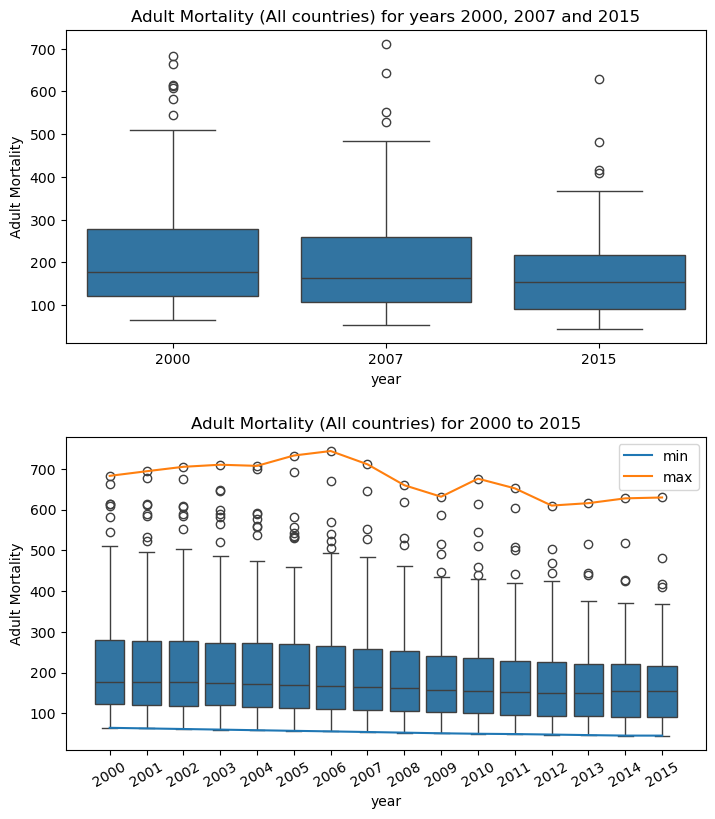

<Figure size 640x480 with 0 Axes>

In [36]:
am_all_2000_2007_2015 = life_expectancy[(life_expectancy['year'] == 2000) | (life_expectancy['year'] == 2015) | (life_expectancy['year'] == 2007)]
am_all_2000_to_2015 = life_expectancy

ax1 = plt.subplot(2, 1, 1)
sns.boxplot(x = am_all_2000_2007_2015['year'], y = am_all_2000_2007_2015['adult_mortality'])
plt.title('Adult Mortality (All countries) for years 2000, 2007 and 2015')
plt.ylabel('Adult Mortality')
plt.subplots_adjust(0, 1, 1, 2.5, 3, 0.3)
ax2 = plt.subplot(2, 1, 2)
sns.boxplot(x = am_all_2000_to_2015['year'], y = am_all_2000_to_2015['adult_mortality'])
plt.title('Adult Mortality (All countries) for 2000 to 2015')
plt.ylabel('Adult Mortality')
plt.xticks(rotation = 30)
plt.plot(descriptive_stats_adult_mortality['minimum'], label = 'min')
plt.plot(descriptive_stats_adult_mortality['max'], label = 'max')
plt.legend()
plt.show()
plt.clf()